In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

In [58]:
df = pd.read_csv(r"E:\ansys\3layer_0p025in\etrap_3layer_RF_spacer_size_0p025in_spacer_cap.txt", delimiter=r"\t", skiprows=6, nrows=29, index_col=0, on_bad_lines='warn')

C:\Users\electron\AppData\Local\Temp\ipykernel_40140\2270685320.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(r"E:\ansys\3layer_0p025in\etrap_3layer_RF_spacer_size_0p025in_spacer_cap.txt", delimiter=r"\t", skiprows=6, nrows=29, index_col=0, on_bad_lines='warn')


In [61]:
df

,Vbl1,Vbl2,Vbl3,Vbl3_trace,Vbl4,Vbl5,Vbr1,Vbr2,Vbr3,Vbr4,...,Vtl1,Vtl2,Vtl3,Vtl4,Vtl5,Vtr1,Vtr2,Vtr3,Vtr4,Vtr5
Vbl1,3.604500,-0.465030,-0.020306,-0.027437,-0.007989,-0.003193,-0.003572,-0.001792,-0.000559,-0.000641,...,-0.004684,-0.002689,-0.000812,-0.000198,-0.000040,-0.000055,-0.000021,-0.000004,-0.000004,-0.000006
Vbl2,-0.465030,3.545300,-0.175980,-0.184740,-0.021675,-0.005631,-0.001418,-0.003043,-0.001322,-0.000814,...,-0.005540,-0.010983,-0.004445,-0.000860,-0.000113,-0.000021,-0.000050,-0.000021,-0.000007,-0.000012
Vbl3,-0.020306,-0.175980,0.887900,-0.050910,-0.172800,-0.014765,-0.000563,-0.001498,-0.002849,-0.001357,...,-0.000004,-0.000042,-0.000161,-0.000048,-0.000005,-0.000003,-0.000021,-0.000052,-0.000021,-0.000003
Vbl3_trace,-0.027437,-0.184740,-0.050910,2.460400,-0.188910,-0.014422,-0.000346,-0.000494,-0.000463,-0.000780,...,-0.002985,-0.006877,-0.013693,-0.006147,-0.000464,-0.000003,-0.000003,-0.000006,-0.000013,-0.000032
Vbl4,-0.007989,-0.021675,-0.172800,-0.188910,3.125900,-0.364470,-0.000743,-0.001135,-0.001889,-0.004182,...,-0.001437,-0.003023,-0.006735,-0.024549,-0.004901,-0.000009,-0.000011,-0.000037,-0.000095,-0.000155
Vbl5,-0.003193,-0.005631,-0.014765,-0.014422,-0.364470,3.056800,-0.001104,-0.001650,-0.002126,-0.005034,...,-0.000433,-0.000949,-0.001731,-0.005146,-0.025285,-0.000015,-0.000021,-0.000053,-0.000197,-0.002294
Vbr1,-0.003572,-0.001418,-0.000563,-0.000346,-0.000743,-0.001104,3.553400,-0.498650,-0.034509,-0.011961,...,-0.000055,-0.000023,-0.000006,-0.000007,-0.000013,-0.010137,-0.006790,-0.002198,-0.000527,-0.000131
Vbr2,-0.001792,-0.003043,-0.001498,-0.000494,-0.001135,-0.001650,-0.498650,4.689900,-0.395440,-0.038882,...,-0.000023,-0.000053,-0.000025,-0.000015,-0.000029,-0.006479,-0.012474,-0.008166,-0.001924,-0.000398
Vbr3,-0.000559,-0.001322,-0.002849,-0.000463,-0.001889,-0.002126,-0.034509,-0.395440,3.524600,-0.322260,...,-0.000006,-0.000027,-0.000065,-0.000056,-0.000095,-0.001981,-0.005437,-0.016453,-0.015657,-0.001608
Vbr4,-0.000641,-0.000814,-0.001357,-0.000780,-0.004182,-0.005034,-0.011961,-0.038882,-0.322260,3.208900,...,-0.000009,-0.000018,-0.000056,-0.000153,-0.000312,-0.000658,-0.001893,-0.005571,-0.023847,-0.006762


In [88]:
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm

def plot_dataframe_heatmap(df, threshold=1.0):
    """
    Plots a heatmap of the absolute values of a 2D DataFrame with:
    - Blue-to-red colormap (coolwarm)
    - Logarithmic color scaling
    - Labels only shown if value > threshold
    - Diagonal values ignored if df is square and labels match
    - Row/column labels trimmed to exclude first character
    - Colorbar labeled as 'Capacitance (pF)'
    - Auto-scaling to fit large DataFrames like 28x28
    """
    # Take absolute values
    df_abs = df.abs().copy()

    # Ignore diagonal if square and labels match
    if df_abs.shape[0] == df_abs.shape[1] and all(df_abs.index == df_abs.columns):
        for idx in df_abs.index:
            df_abs.loc[idx, idx] = np.nan

    # Trim first character from headers for labeling
    trimmed_rows = [str(i)[1:] for i in df_abs.index]
    trimmed_cols = [str(i)[1:] for i in df_abs.columns]

    # Generate annotation labels only for values > threshold
    annot = df_abs.applymap(lambda x: f"{x:.2f}" if pd.notnull(x) and x > threshold else "")

    # Replace non-positive values for log scale
    display_data = df_abs.copy()
    min_nonzero = np.nanmin(display_data[display_data > 0])
    display_data[display_data <= 0] = min_nonzero / 10

    # Determine figure size based on number of cells
    fig_width = max(12, df.shape[1] * 0.35)
    fig_height = max(12, df.shape[0] * 0.35)

    # Plotting
    plt.figure(figsize=(fig_width, fig_height))
    ax = sns.heatmap(
        display_data,
        annot=annot,
        fmt='',
        cmap='coolwarm',
        norm=LogNorm(vmin=np.nanmin(display_data.values), vmax=np.nanmax(display_data.values)),
        linewidths=0.3,
        linecolor='gray',
        cbar=True,
        xticklabels=trimmed_cols,
        yticklabels=trimmed_rows,
        annot_kws={"size": 7}
    )


    # Set colorbar label
    cbar = ax.collections[0].colorbar
    cbar.set_label("Capacitance (pF)")

    # Smaller ticks for large grids
    ax.tick_params(axis='x', labelrotation=90)
    ax.tick_params(axis='y')

    plt.tight_layout()
    plt.savefig('Cap_map.png')
    plt.show()

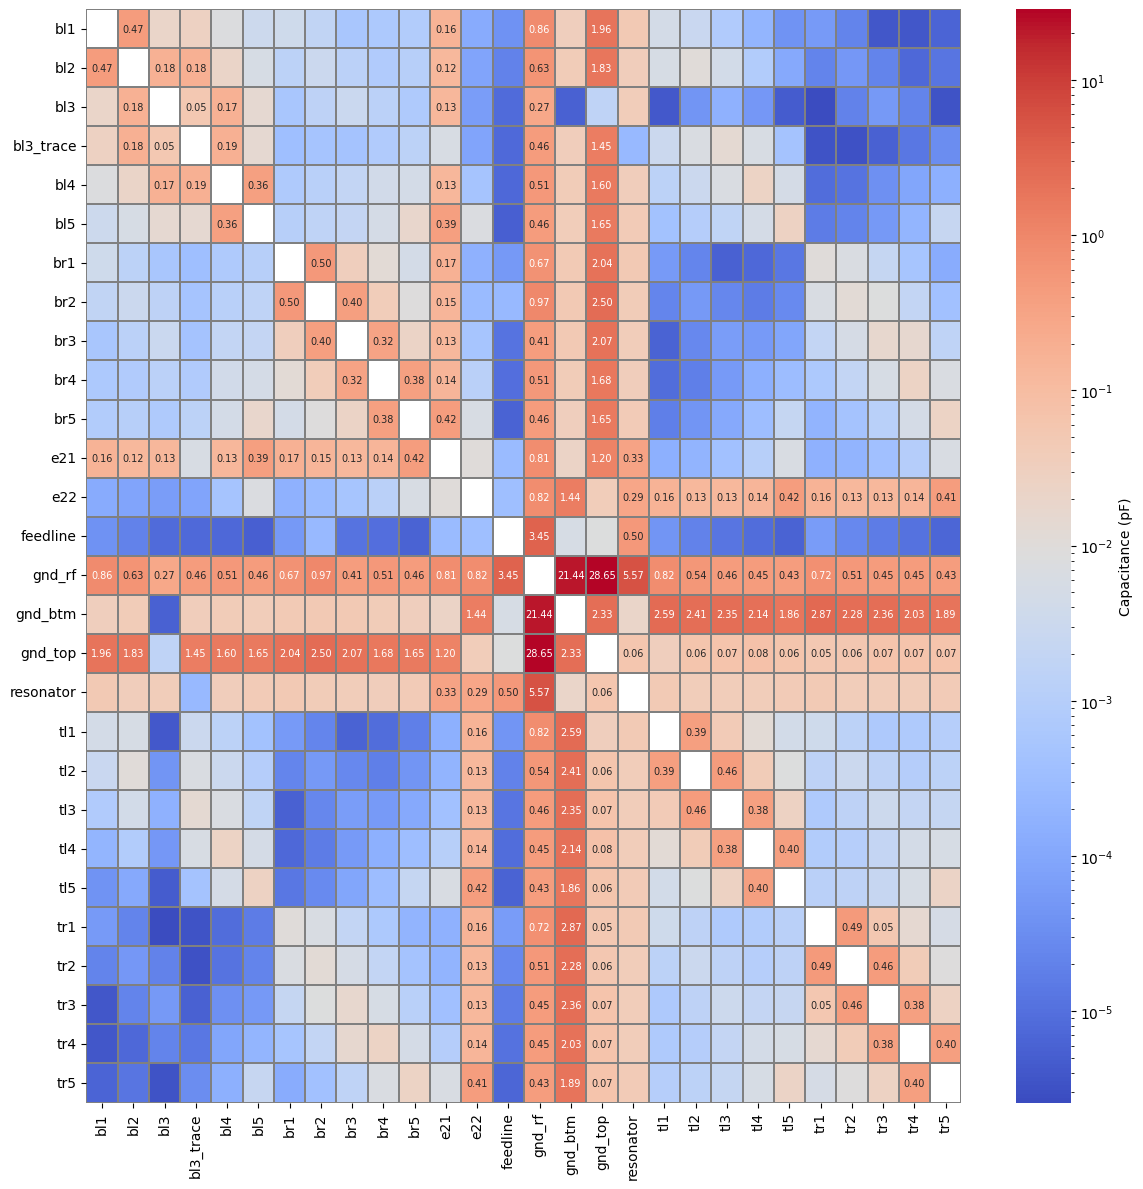

In [89]:
plot_dataframe_heatmap(df, threshold=0.05)

In [35]:
from edes.modules.resonator.resonator_utils import plot_S21, cutoff_x0, plot, get_Qi, get_S21_fit, S21_mag, percent_to_dB, plot_ax

In [36]:
def plot_S21(f, S, cutoff_freq=3, f0_guess=2): 
    f, S = cutoff_x0(f, S, cutoff_freq)

    f0, Q, Qc_mag, a, alpha, t, phi = get_S21_fit(f, S, f0=f0_guess)
    plot(f, S, '.', label='Ansys Simulation')
    
    ft = np.linspace(min(f), max(f), 500000)
    St = S21_mag(ft, f0, Q, Qc_mag, a, alpha, t, phi)
    St_dB = percent_to_dB(St)

    Qc = Qc_mag*np.exp(-1j*phi).real
    plot(ft, St_dB, '--', label=f'Fit, $f_0$ = {f0:.2f}GHz, \n$Q_i$ = {get_Qi(Q, Qc):.2f}, \n$Q_c$ = {Qc:.2f}, \n$Q$ = {Q:.2f}')

    id0 = np.where(ft < f0)[0][-1]
    idl, idr = np.argmin(abs(St_dB[:id0]-(max(St_dB)-3))), id0+np.argmin(abs(St_dB[id0:]-(max(St_dB)-3)))
    plot(ft[idl], St_dB[idl], 'gX')
    plot(ft[idr], St_dB[idr], 'gX', label=f'-3dB, $Q$ = {f0/abs(ft[idr]-ft[idl]):.2f}', xlabel='f (GHz)', ylabel='$|S_{21}|$ (dB)')
    plt.legend()

In [37]:
plot_S21(r"HFSS_0p025in", f0_guess=1.5, base=r'E:\ansys\3layer_0p025in')

TypeError: plot_S21() got an unexpected keyword argument 'base'

In [38]:
df = pd.read_csv(r"E:/ansys/3layer_0p025in/HFSS_0p025in.csv")
f, S = np.array(df[df.keys()[0]]), np.array(df[df.keys()[2]])

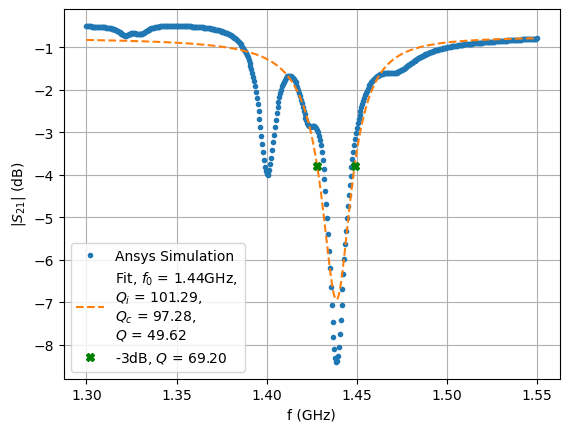

In [18]:
plot_S21(f, S, f0_guess=1.5)

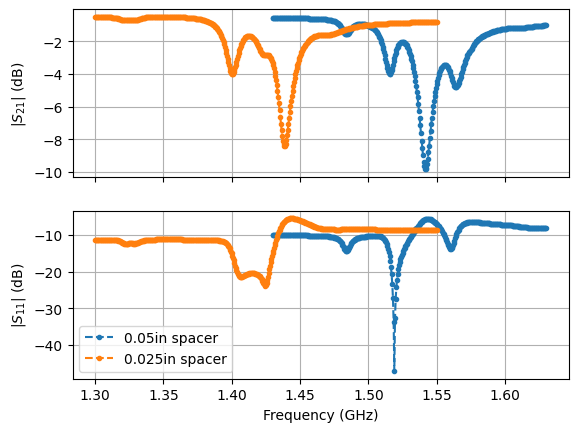

In [52]:
dfl = pd.read_csv(r"E:/ansys/3layer_0p025in/HFSS_0p05in.csv")
fl, S21l, S11l = np.array(dfl["Freq [GHz]"]), np.array(dfl["dB(St(feedline_T2,feedline_T1)) []"]), np.array(dfl["dB(St(feedline_T1,feedline_T1)) []"])
dfs = pd.read_csv(r"E:/ansys/3layer_0p025in/HFSS_0p025in.csv")
fs, S21s, S11s = np.array(dfs["Freq [GHz]"]), np.array(dfs["dB(St(feedline_T2,feedline_T1)) [] - coupling_gap='0in' coupling_l='0.8in' gap='0.02in' wguide_gap='0.006in'"]), np.array(dfs["dB(St(feedline_T1,feedline_T1)) [] - coupling_gap='0in' coupling_l='0.8in' gap='0.02in' wguide_gap='0.006in'"])

fig, (ax, ax2) = plt.subplots(nrows=2, sharex=True)
plot_ax(ax, fl, S21l, '.--', label='0.05in spacer') 
plot_ax(ax, fs, S21s, '.--', label='0.025in spacer', ylabel=r'$|S_{21}|$ (dB)')
plot_ax(ax2, fl, S11l, '.--', label='0.05in spacer') 
plot_ax(ax2, fs, S11s, '.--', label='0.025in spacer', ylabel=r'$|S_{11}|$ (dB)', xlabel='Frequency (GHz)')

plt.legend() 
plt.savefig('S_params.png')
plt.show()